In [24]:
import numpy as np
import time, os, sys
import functools
import argparse
import vegas
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels, PLaxfromClass
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

parser = argparse.ArgumentParser(description="Compute P1-loop with fx component")

#===============================
# Compute P_{c,chi} one-loop terms
# It seems that I am computing also the full P_{c,c}, but in reality the EdS integral here
# is the P_{c,chi} one with EdS kernels, to compare the full result to
#===============================

# physical
fx=0.1
ma=1.e-27
zeval=0.5

p=2

# kevList=np.logspace(np.log10(0.05),np.log10(0.5),30)
kevList=np.logspace(np.log10(0.05),np.log10(0.6),30)

# kevList = [0.44011]

# technical
fullt=np.linspace(-6,1, 200)
idx_eta=np.abs(fullt - (0.)).argmin()
rtol=0.1
supprshift=5
fact=(2*np.pi)**3

h=0.67810
kref =8.4e12 * pow(ma/h,1/2) * 0.666**0.25

In [21]:
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=rtol, p=p)
plclass = PLaxfromClass(fx=fx, m_a_ev=ma, zeval=zeval)
PLc_int = plclass.PLc_int
def g_numk(k):
    return nk.g_num(-(2+p)*np.log(k/kref))

In [22]:
fact=(2*np.pi)**3

def F3(k,q,mu):
    k2=k*k;q2=q*q;mu2=mu*mu
    kMq2 = k2 + q2 - 2*k*q*mu 
    kPq2 = k2 + q2 + 2*k*q*mu 

    res1 = 1/kMq2*(5/126*k2-11/108*k*q*mu+7/108*q2*mu2-1/54*k2*k2*mu2/q2+4/189*k2*k*mu2*mu/q-23/756*k2*k*mu/q+25/252*k2*mu2-2/27*k*q*mu2*mu)
    res2 = 1/kPq2*(5/126*k2+11/108*k*q*mu-7/108*q2*mu2-4/27*k2*k2*mu2/q2-53/189*k2*k*mu2*mu/q+23/756*k2*k*mu/q-121/756*k2*mu2-5/27*k*q*mu2*mu)
    return res1+res2
def F2(k,q,mu):
    k2=k*k;q2=q*q;mu2=mu*mu
    kMq2 = k2 + q2 - 2*k*q*mu 
    return (k2*(7*k*q*mu+3*q2)-10*k2*q2*mu2)/(14*q2*kMq2)

def alpha(k1,k2,cT):
    return 1+cT*k2/k1

def alphas(k1,k2,cT):
    return 1+0.5*cT*(k2/k1+k1/k2)

def beta(k1,k2,cT):
    t1=k1*k1+k2*k2+2*k1*k2*cT
    t2=k1*k2*cT
    t3=2.*k1*k1*k2*k2
    return t1*t2/t3

def F3_IR(k,q,mu):
    return -1/6*mu**2 * (k/q)**2
def F2_IR(k,q,mu):
    return 1/2*mu * (k/q)

In [66]:
kevList=np.logspace(np.log10(0.05),np.log10(0.6),30)
reslist=[]
def P1loop_EdSIR_int(vars,kev, PL_int):
    q=vars[0]
    mu=vars[1]
    P13=6*q*q*g_numk(kev)*F3_IR(kev,q,mu)*PL_int(q)*PL_int(kev)
    kMq = np.sqrt(kev*kev + q*q - 2*kev*q*mu)
    kPq = np.sqrt(kev*kev + q*q + 2*kev*q*mu)
    P22=0
    if kMq>q:
        P22+=2*q*q*g_numk(kev)*(F2_IR(kev,q,mu)**2)*PL_int(q)*PL_int(kMq)
    if kPq>q:
        P22+=2*q*q*g_numk(kev)*(F2_IR(kev,q,-mu)**2)*PL_int(q)*PL_int(kPq)
    return [P22*4*np.pi/fact,P13*4*np.pi/fact]


integ = vegas.Integrator([[1.e-3, 1], [0., 1.]],mpi=True, nproc=48)

print('Training')
result22, result13 = integ(functools.partial(P1loop_EdSIR_int, kev=0.1, PL_int=PLc_int),neval=10000)
print('Applying')

Neval = 1000
reslist = np.array(list(reslist))
reslist=[]
for kev in kevList:
    result22, result13  = integ(functools.partial(P1loop_EdSIR_int, kev=kev, PL_int=PLc_int),neval=Neval)

    reslist.append([kev, result22.mean, result13.mean])
    print(f'Computing at k={kev:.3f}', end='\r')
_, dcdx22_IR, dcdx13_IR = np.array(reslist).T

Training
Applying


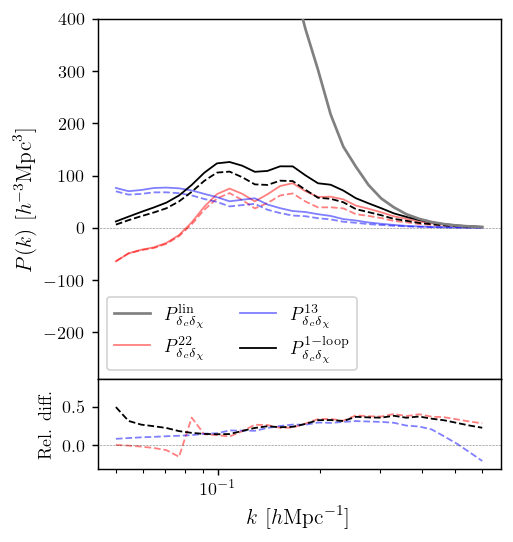

In [67]:
k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P22-ma27p0-fx0p1-N1000-p2.txt', unpack=True)[:,:70]

k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x  =np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/results/P13-ma27p0-fx0p1-N1000-p2.txt', unpack=True)[:,:70]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), dpi=130, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.0})

# Upper panel
ax1.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
ax1.plot(k, dcdx22+dcdx13_IR, 'r', label=r'$P^{22}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.5)
ax1.plot(k, dcdx22_EdS+dcdx13_IR, 'r--', linewidth=1, alpha=0.5)
ax1.plot(k, dcdx13-dcdx13_IR, 'b', label=r'$P^{13}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.5)
ax1.plot(k, dcdx13_EdS-dcdx13_IR, 'b--', linewidth=1, alpha=0.5)
# ax1.plot(k, dcdx13_IR, 'c--', linewidth=1)
# ax1.plot(k, dcdx22_IR, 'm--', linewidth=1)

ax1.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax1.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
ax1.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax1.set_xscale('log')
# ax1.set_yscale('log')

ax1.set_ylim([-290, 400])

ax1.legend(fontsize=10, loc='best', ncol=2)
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

# Lower panel (relative differences)
relative_diff_22 = (dcdx22 - dcdx22_EdS)/(dcdx22+ dcdx13_IR) #/ dcdx22
relative_diff_13 = (dcdx13 - dcdx13_EdS) /(dcdx13- dcdx13_IR)# / dcdx13
relative_diff_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)

ax2.plot(k, relative_diff_22, 'r', label=r'Rel. diff. $P^{22}$', linewidth=1, alpha=0.5, linestyle='--')
ax2.plot(k, relative_diff_13, 'b', label=r'Rel. diff. $P^{13}$', linewidth=1, alpha=0.5, linestyle='--')
ax2.plot(k, relative_diff_total, 'k', linewidth=1, linestyle='--')
ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)

ax2.set_ylim([-0.31,0.85])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel('Rel. diff.', fontsize=10)
# ax1.set_xlim([0.08, None])
# ax2.set_xlim([0.08, None])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')

plt.show()

In [53]:
k=0.1
y=1/100000
print(F3(k,k*y,0.5),F3_IR(k,k*y,0.5))
print(F2(k,k*y,1),F2_IR(k,k*y,1))


-416666666.595238 -416666666.6666665
50000.500005000045 49999.99999999999
